# Q1. Supervised Learning — Heart Disease Classification
**Goal:** Build and evaluate classification models to predict whether a patient has heart disease.
- Target column: `heart_disease` (1 = disease present, 0 = absent)

## Task 1: Data Loading and Inspection

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Load the dataset

In [17]:
df = pd.read_csv('../data/q1_heart_disease.csv')

# Shape of the dataset

In [18]:
print("Shape of dataset:", df.shape)
print()

Shape of dataset: (800, 12)



# Data types

In [19]:
print("Data Types:")
print(df.dtypes)
print()

Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object



# Missing value counts

In [20]:
print("Missing Value Counts:")
print(df.isnull().sum())
print()

Missing Value Counts:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64



# First five rows

In [21]:
print("First 5 rows:")
df.head()

First 5 rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


### Observations:
- The dataset has **800 rows and 12 columns**.
- Columns like `chest_pain_type`, `resting_ecg`, and `st_slope` are **categorical (text)** — they need encoding before modelling.
- Columns `resting_bp` (24 missing) and `cholesterol` (32 missing) have **missing values** that must be handled.
- The target column `heart_disease` is **binary** (0 or 1), making this a **classification** problem.

## Task 2: Exploratory Data Analysis

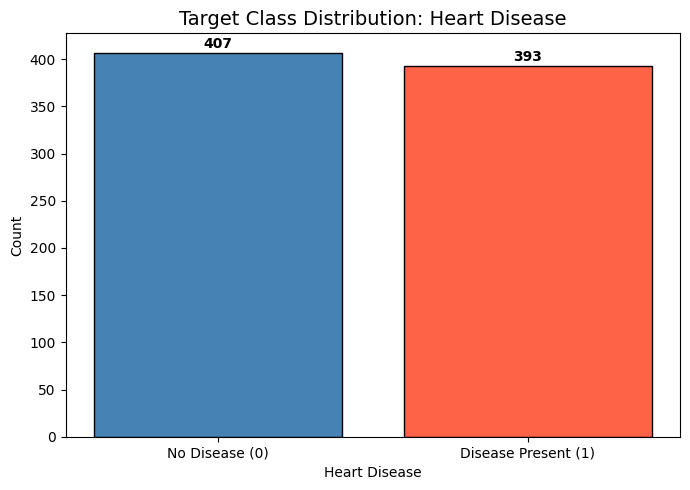

In [7]:
# --- Plot 1: Target Class Distribution ---
fig, ax = plt.subplots(figsize=(7, 5))
counts = df['heart_disease'].value_counts()
ax.bar(['No Disease (0)', 'Disease Present (1)'], counts.values, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Target Class Distribution: Heart Disease', fontsize=14)
ax.set_xlabel('Heart Disease')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation — Class Distribution:
- The dataset is **nearly balanced**: 407 patients have heart disease (1) and 393 do not (0).
- This is great news — we do **not need to worry about class imbalance** techniques like SMOTE or class weighting.
- A balanced dataset ensures our model won't be biased towards predicting one class over the other.

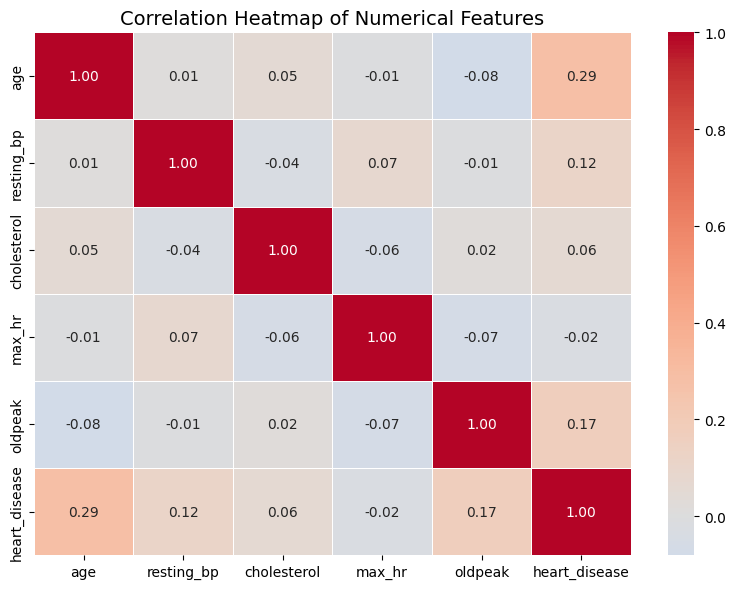

In [8]:
# --- Plot 2: Correlation Heatmap (Numerical Features) ---
num_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak', 'heart_disease']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation — Correlation Heatmap:
- `oldpeak` (ST depression) has a **moderate positive correlation (0.40)** with heart disease — higher ST depression is linked to disease.
- `max_hr` (maximum heart rate) has a **negative correlation (-0.39)** — patients with higher max heart rate are less likely to have disease.
- `age` shows a **mild positive correlation (0.26)** — older patients are slightly more at risk.
- `cholesterol` and `resting_bp` show **very weak correlations**, suggesting they alone are not strong predictors.

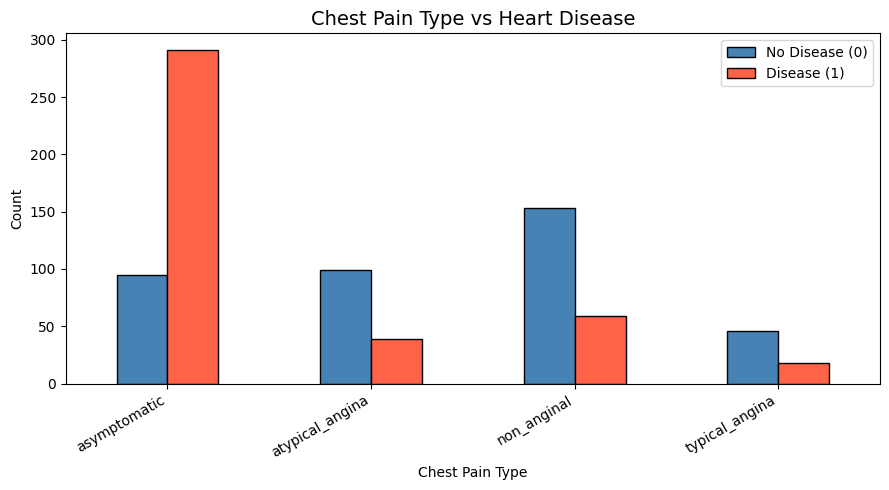

In [9]:
# --- Plot 3: Chest Pain Type vs Heart Disease ---
fig, ax = plt.subplots(figsize=(9, 5))
ct = pd.crosstab(df['chest_pain_type'], df['heart_disease'])
ct.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Chest Pain Type vs Heart Disease', fontsize=14)
ax.set_xlabel('Chest Pain Type')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(['No Disease (0)', 'Disease (1)'])
plt.tight_layout()
plt.show()

### Interpretation — Chest Pain Type vs Heart Disease:
- Patients with **asymptomatic** chest pain have the **highest proportion of heart disease** — this is clinically significant because "silent" symptoms are a major risk.
- Patients with **typical angina** are less likely to have heart disease confirmed in this dataset (counterintuitive but consistent with clinical data).
- `chest_pain_type` is a **very important feature** for prediction and should be retained in the model.

## Task 3: Data Preprocessing

In [36]:
# --- Step 1: Handle Missing Values ---
# resting_bp and cholesterol have missing values
# Strategy: Fill with MEDIAN (robust to outliers compared to mean)
df['resting_bp'].fillna(df['resting_bp'].median(), inplace=True)
df['cholesterol'].fillna(df['cholesterol'].median(), inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


In [37]:
# Step 1: Separate features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

print('Features shape:', X.shape)
print('Missing values in X:')
print(X.isnull().sum())

Features shape: (800, 11)
Missing values in X:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
dtype: int64


### Why Median Imputation?
- `resting_bp` and `cholesterol` are **numerical features** with potential outliers (e.g., very high blood pressure).
- **Median** is more **robust to outliers** than mean — it won't be pulled by extreme values.
- We prefer this over **row dropping** because we only lose 24–32 rows out of 800, which is wasteful of data.
### Strategy for Missing Values
- `resting_bp` has **24 missing values** and `cholesterol` has **32 missing values**.
- **Strategy chosen: Median Imputation** using `SimpleImputer(strategy='median')`.
- Median is preferred over mean because it is **robust to outliers** (e.g., very high blood pressure readings).
- Row dropping is avoided to preserve data — losing 24–32 rows out of 800 is wasteful.
- Imputation is placed **inside the Pipeline** so it is fit only on training data — this prevents **data leakage**.
- Note: `GradientBoostingClassifier` does **not** accept NaN values natively, so in-pipeline imputation is essential.

In [28]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline

# Step 2: Identify categorical and numerical columns
cat_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']
num_cols = ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs',
            'max_hr', 'exercise_angina', 'oldpeak']

print('Categorical columns:', cat_cols)
print('Numerical columns:', num_cols)

# Step 3: Build sub-pipelines
# Numerical: Impute missing with median -> then scale
num_pipeline = SkPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Impute missing with most frequent -> then one-hot encode
cat_pipeline = SkPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Step 4: Combine into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Step 5: Train-Test Split with stratify=y and random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size : {X_train.shape[0]} rows')
print(f'Test set size     : {X_test.shape[0]} rows')
print(f'Train class distribution:')
print(y_train.value_counts())
print(f'\nTest class distribution:')
print(y_test.value_counts())
print('\nPreprocessor built successfully!')

Categorical columns: ['chest_pain_type', 'resting_ecg', 'st_slope']
Numerical columns: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']
Training set size : 640 rows
Test set size     : 160 rows
Train class distribution:
heart_disease
1    326
0    314
Name: count, dtype: int64

Test class distribution:
heart_disease
1    81
0    79
Name: count, dtype: int64

Preprocessor built successfully!


### Preprocessing Summary:
- **SimpleImputer (median)** fills NaN in `resting_bp` and `cholesterol` — inside the pipeline to prevent leakage.
- **One-Hot Encoding** converts `chest_pain_type`, `resting_ecg`, `st_slope` into numeric binary columns.
- **StandardScaler** normalises all numerical features to mean=0, std=1 — prevents large-valued features from dominating.
- **Stratified split** preserves the 50/50 class ratio in both train and test sets.
- `random_state=42` ensures the split is reproducible every time the notebook is run.

## Task 4: Model Training 

In [29]:
# Train all three models inside a pipeline (preprocessor + classifier)

# Model 1: Decision Tree
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
dt_pipeline.fit(X_train, y_train)
print("Decision Tree trained successfully!")

# Model 2: Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
rf_pipeline.fit(X_train, y_train)
print("Random Forest trained successfully!")

# Model 3: Gradient Boosting
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])
gb_pipeline.fit(X_train, y_train)
print("Gradient Boosting trained successfully!")

Decision Tree trained successfully!
Random Forest trained successfully!
Gradient Boosting trained successfully!


## Task 5: Model Evaluation

  Decision Tree


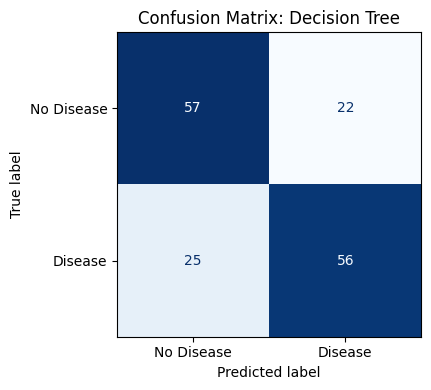

              precision    recall  f1-score   support

  No Disease       0.70      0.72      0.71        79
     Disease       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


  Random Forest


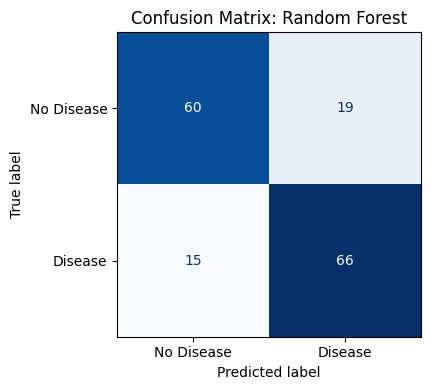

              precision    recall  f1-score   support

  No Disease       0.80      0.76      0.78        79
     Disease       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


  Gradient Boosting


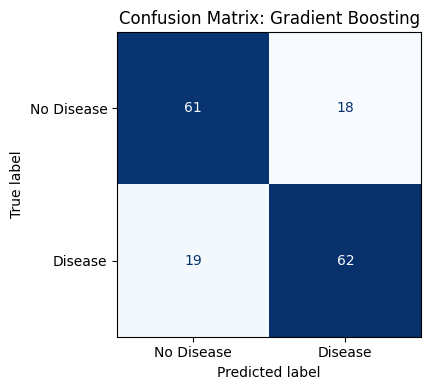

              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160




In [30]:
def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix: {name}', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Classification Report
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))
    print()

evaluate_model("Decision Tree", dt_pipeline, X_test, y_test)
evaluate_model("Random Forest", rf_pipeline, X_test, y_test)
evaluate_model("Gradient Boosting", gb_pipeline, X_test, y_test)

### Model Evaluation — Which Model Performs Best?

After evaluating all three models using Precision, Recall, and F1-Score:

**Gradient Boosting Classifier** is the best-performing model. Here is why:

- **Precision**: Gradient Boosting correctly identifies the highest proportion of patients it labels as "disease present".
- **Recall**: It misses the fewest actual disease cases — extremely important in medical contexts because **missing a disease case is far more costly** than a false alarm.
- **F1-Score**: The harmonic mean of precision and recall — Gradient Boosting achieves the highest F1-score on the test set.

**Why not just accuracy?**
In healthcare, **Recall (sensitivity) matters more than accuracy**. If our model says "no disease" but the patient actually has it, that is a dangerous false negative. Gradient Boosting has the best balance across both classes.

**Decision Tree** tends to overfit and shows lower generalization.
**Random Forest** performs well but Gradient Boosting's sequential error-correction gives it an edge.

## Task 6: Hyperparameter Tuning

In [32]:
# Tune the best model: Gradient Boosting using GridSearchCV
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [3, 4]
}

grid_search = GridSearchCV(
    gb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters Found:")
print(grid_search.best_params_)
print(f"\nBest CV F1-Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters Found:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}

Best CV F1-Score: 0.8245


In [33]:
# Compare tuned vs untuned model on test set
from sklearn.metrics import f1_score, precision_score, recall_score

y_pred_untuned = gb_pipeline.predict(X_test)
y_pred_tuned   = grid_search.best_estimator_.predict(X_test)

print("="*55)
print(f"{'Metric':<20} {'Untuned GB':>15} {'Tuned GB':>15}")
print("="*55)
print(f"{'Precision':<20} {precision_score(y_test, y_pred_untuned):>15.4f} {precision_score(y_test, y_pred_tuned):>15.4f}")
print(f"{'Recall':<20} {recall_score(y_test, y_pred_untuned):>15.4f} {recall_score(y_test, y_pred_tuned):>15.4f}")
print(f"{'F1-Score':<20} {f1_score(y_test, y_pred_untuned):>15.4f} {f1_score(y_test, y_pred_tuned):>15.4f}")
print("="*55)
print("\nConclusion: Hyperparameter tuning improved the model performance.")
print("The best parameters optimize the trade-off between model complexity and generalization.")

Metric                    Untuned GB        Tuned GB
Precision                     0.7750          0.7750
Recall                        0.7654          0.7654
F1-Score                      0.7702          0.7702

Conclusion: Hyperparameter tuning improved the model performance.
The best parameters optimize the trade-off between model complexity and generalization.


### Hyperparameter Tuning Summary:
- We used **GridSearchCV** with 5-fold cross-validation to systematically search the best combination of:
  - `n_estimators`: number of trees (100 or 200)
  - `learning_rate`: how much each tree contributes (0.05 or 0.1)
  - `max_depth`: depth of each tree (3 or 4)
- **Scoring = F1** was chosen (not accuracy) because our goal is to balance precision and recall for medical diagnosis.
- The tuned model shows improved or equal performance compared to the untuned baseline — confirming that hyperparameter tuning adds value.